In [13]:
import time
import os
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F

import torchquantum as tq
import numpy as np

from e2cnn import gspaces
from e2cnn import nn as e2nn

import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc, f1_score)
from sklearn.preprocessing import label_binarize
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)

os.environ["OMP_NUM_THREADS"] = "1"

print(f"TorchQuantum version: {tq.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

TorchQuantum version: 0.1.8
PyTorch version: 2.5.1+cu121
CUDA available: True


In [14]:
# Quantum: 8-qubit p4m Equivariant QCNN (33 trainable quantum params)
n_qubits = 8

# Training
step = 0.001
batch_size = 64
weight_decay = 1e-5
num_epochs = 50
patience = 12
WARMUP_EPOCHS = 5

# Model
img_size = 150
in_channels = 1
num_classes = 3
DROPOUT_RATE = 0.3

# Data paths — UPDATE THESE
train_dir = "/home/jovyan/work/dataset/dataset/train"
val_dir = "/home/jovyan/work/dataset/dataset/val"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Architecture: p4m Equivariant QCNN (from EQNN_for_HEP)")
print(f"Quantum: {n_qubits} qubits, 33 trainable params (3 conv × 6 + 3 pool × 5)")
print(f"Image size: {img_size}x{img_size}, Classes: {num_classes}")
print(f"Device: {device}")

Architecture: p4m Equivariant QCNN (from EQNN_for_HEP)
Quantum: 8 qubits, 33 trainable params (3 conv × 6 + 3 pool × 5)
Image size: 150x150, Classes: 3
Device: cuda:0


In [15]:
class NPYImageFolder(Dataset):
    """Dataset loader for .npy image files organized in class folders."""

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.classes = sorted([d for d in os.listdir(root_dir)
                               if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            for filename in os.listdir(class_dir):
                if filename.endswith('.npy'):
                    filepath = os.path.join(class_dir, filename)
                    self.samples.append((filepath, self.class_to_idx[class_name]))

        print(f"Found {len(self.samples)} samples in {root_dir}")
        print(f"Classes: {self.classes}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filepath, label = self.samples[idx]
        arr = np.load(filepath, allow_pickle=True)

        if isinstance(arr, np.ndarray) and arr.ndim == 0:
            arr = arr.item()
        if isinstance(arr, (list, tuple)):
            arr = arr[0]

        if arr.ndim == 2:
            arr = arr[np.newaxis, :, :]
        elif arr.ndim == 3 and arr.shape[0] not in [1, 3]:
            arr = arr.transpose(2, 0, 1)

        if arr.max() > 1.0:
            arr = arr / arr.max()

        tensor = torch.tensor(arr, dtype=torch.float32)

        if self.transform:
            tensor = self.transform(tensor)

        return tensor, label


class NPYTransform:
    """Transform for NPY images with optional augmentation."""

    def __init__(self, img_size, augment=False):
        self.img_size = img_size
        self.augment = augment

    def __call__(self, x):
        if x.shape[-1] != self.img_size or x.shape[-2] != self.img_size:
            x = F.interpolate(x.unsqueeze(0), size=(self.img_size, self.img_size),
                              mode='bilinear', align_corners=False).squeeze(0)

        if self.augment:
            if torch.rand(1) > 0.5:
                k = torch.randint(0, 4, (1,)).item()
                if k > 0:
                    x = torch.rot90(x, k, dims=[-2, -1])
            if torch.rand(1) > 0.5:
                x = torch.flip(x, dims=[-1])
            if torch.rand(1) > 0.5:
                x = torch.flip(x, dims=[-2])
            if torch.rand(1) > 0.7:
                noise_std = torch.rand(1).item() * 0.03
                noise = torch.randn_like(x) * noise_std
                x = torch.clamp(x + noise, 0, 1)
            if torch.rand(1) > 0.7:
                bf = 0.8 + torch.rand(1).item() * 0.4
                x = torch.clamp(x * bf, 0, 1)

        return x


def get_dataloaders(train_dir, val_dir, img_size, batch_size, test_split=0.10):
    """Create train, validation, and test dataloaders."""
    train_transform = NPYTransform(img_size, augment=True)
    val_transform = NPYTransform(img_size, augment=False)

    train_dataset = NPYImageFolder(train_dir, train_transform)
    val_full_dataset = NPYImageFolder(val_dir, val_transform)

    total_val = len(val_full_dataset)
    test_size = int(total_val * test_split)
    val_size = total_val - test_size

    val_dataset, test_dataset = random_split(
        val_full_dataset, [val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                            num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                             num_workers=0, pin_memory=True)

    return train_loader, val_loader, test_loader, train_dataset.classes

In [16]:
class EquivariantQCNN(tq.QuantumModule):
    """
    p4m Equivariant Quantum Convolutional Neural Network (TorchQuantum).

    Translated from EQNN_for_HEP (Lazaro Diaz Lievano, QMLHEP/ML4SCI).
    Uses equivariant U2 gates (RX + IsingZZ + RX + IsingYY) and
    equivariant pooling (RX + RY + RZ + CRX).

    Structure:
        Conv1 (8 qubit pairs) → Pool1 (8→4) →
        Conv2 (4 qubit pairs) → Pool2 (4→2) →
        Conv3 (2 qubit pair)  → Pool3 (2→1) → H(4)

    Trainable quantum parameters: 33 (3×6 conv + 3×5 pool)
    """

    def __init__(self, n_qubits=8):
        super().__init__()
        self.n_qubits = n_qubits

        self.conv1_params = nn.Parameter(0.1 * torch.randn(6))
        self.conv2_params = nn.Parameter(0.1 * torch.randn(6))
        self.conv3_params = nn.Parameter(0.1 * torch.randn(6))

        self.pool1_params = nn.Parameter(0.1 * torch.randn(5))
        self.pool2_params = nn.Parameter(0.1 * torch.randn(5))
        self.pool3_params = nn.Parameter(0.1 * torch.randn(5))

        self.measure = tq.MeasureAll(tq.PauliZ)

    def _expand(self, params, bsz):
        return params.unsqueeze(0).expand(bsz, -1)

    def _ising_zz(self, qdev, theta, w0, w1):
        """IsingZZ(θ) = exp(-iθ/2 Z⊗Z) via CNOT-RZ-CNOT."""
        qdev.cnot(wires=[w0, w1])
        qdev.rz(wires=w1, params=theta)
        qdev.cnot(wires=[w0, w1])

    def _ising_yy(self, qdev, theta, w0, w1, pi2):
        """IsingYY(θ) = exp(-iθ/2 Y⊗Y) via RX(±π/2) basis change + ZZ."""
        qdev.rx(wires=w0, params=pi2)
        qdev.rx(wires=w1, params=pi2)
        qdev.cnot(wires=[w0, w1])
        qdev.rz(wires=w1, params=theta)
        qdev.cnot(wires=[w0, w1])
        qdev.rx(wires=w0, params=-pi2)
        qdev.rx(wires=w1, params=-pi2)

    def _u2_equiv(self, qdev, p, w0, w1, pi2):
        """Equivariant U2 gate: RX-RX-IsingZZ-RX-RX-IsingYY (6 params)."""
        qdev.rx(wires=w0, params=p[:, 0])
        qdev.rx(wires=w1, params=p[:, 1])
        self._ising_zz(qdev, p[:, 2], w0, w1)
        qdev.rx(wires=w0, params=p[:, 3])
        qdev.rx(wires=w1, params=p[:, 4])
        self._ising_yy(qdev, p[:, 5], w0, w1, pi2)

    def _crx_decomposed(self, qdev, theta, ctrl, tgt):
        """CRX(θ) decomposed as H-RZ(θ/2)-CNOT-RZ(-θ/2)-CNOT-H."""
        qdev.h(wires=tgt)
        qdev.rz(wires=tgt, params=theta / 2)
        qdev.cnot(wires=[ctrl, tgt])
        qdev.rz(wires=tgt, params=-theta / 2)
        qdev.cnot(wires=[ctrl, tgt])
        qdev.h(wires=tgt)

    def _pool_equiv(self, qdev, p, w0, w1):
        """Equivariant pooling: RX-RX-RY-RZ-CRX (5 params). Pools w0 → w1."""
        qdev.rx(wires=w1, params=p[:, 0])
        qdev.rx(wires=w0, params=p[:, 1])
        qdev.ry(wires=w0, params=p[:, 2])
        qdev.rz(wires=w0, params=p[:, 3])
        self._crx_decomposed(qdev, p[:, 4], w0, w1)

    def forward(self, q_in):
        bsz = q_in.shape[0]
        dev = q_in.device

        qdev = tq.QuantumDevice(n_wires=self.n_qubits, bsz=bsz, device=dev)
        pi2 = torch.full((bsz,), np.pi / 2, device=dev, dtype=q_in.dtype)

        c1 = self._expand(self.conv1_params, bsz)
        p1 = self._expand(self.pool1_params, bsz)
        c2 = self._expand(self.conv2_params, bsz)
        p2 = self._expand(self.pool2_params, bsz)
        c3 = self._expand(self.conv3_params, bsz)
        p3 = self._expand(self.pool3_params, bsz)

        # Angle encoding via RY
        for i in range(self.n_qubits):
            qdev.ry(wires=i, params=q_in[:, i])

        # Conv1: U2_equiv on adjacent pairs + cross pairs (weight-shared)
        for i in range(4):
            self._u2_equiv(qdev, c1, 2 * i, 2 * i + 1, pi2)
        self._u2_equiv(qdev, c1, 1, 2, pi2)
        self._u2_equiv(qdev, c1, 5, 6, pi2)
        self._u2_equiv(qdev, c1, 0, 3, pi2)
        self._u2_equiv(qdev, c1, 4, 7, pi2)

        # Pool1: 8 → 4 active qubits (odd → even)
        for i in range(4):
            self._pool_equiv(qdev, p1, 2 * i + 1, 2 * i)

        # Conv2: U2_equiv on remaining pairs (0,2) and (4,6)
        self._u2_equiv(qdev, c2, 0, 2, pi2)
        self._u2_equiv(qdev, c2, 4, 6, pi2)

        # Pool2: 4 → 2 active qubits
        self._pool_equiv(qdev, p2, 2, 0)
        self._pool_equiv(qdev, p2, 6, 4)

        # Conv3: U2_equiv on final pair (0, 4)
        self._u2_equiv(qdev, c3, 0, 4, pi2)

        # Pool3: 2 → 1 active qubit
        self._pool_equiv(qdev, p3, 0, 4)

        # Hadamard on output qubit
        qdev.h(wires=4)

        return self.measure(qdev)

In [17]:
from e2cnn import gspaces
from e2cnn import nn as e2nn


class C8SteerableCNN_Features(nn.Module):
    """C8 Steerable CNN for rotation-equivariant feature extraction."""

    def __init__(self, n_rotations=4):
        super().__init__()

        self.r2_act = gspaces.Rot2dOnR2(N=n_rotations)

        in_type = e2nn.FieldType(self.r2_act, [self.r2_act.trivial_repr])
        self.input_type = in_type

        out_type = e2nn.FieldType(self.r2_act, 24 * [self.r2_act.regular_repr])
        self.block1 = e2nn.SequentialModule(
            e2nn.MaskModule(in_type, 150, margin=1),
            e2nn.R2Conv(in_type, out_type, kernel_size=7, padding=1, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )

        in_type = self.block1.out_type
        out_type = e2nn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block2 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )
        self.pool1 = e2nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        in_type = self.block2.out_type
        out_type = e2nn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block3 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )

        in_type = self.block3.out_type
        out_type = e2nn.FieldType(self.r2_act, 96 * [self.r2_act.regular_repr])
        self.block4 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )
        self.pool2 = e2nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        in_type = self.block4.out_type
        out_type = e2nn.FieldType(self.r2_act, 96 * [self.r2_act.regular_repr])
        self.block5 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )

        in_type = self.block5.out_type
        out_type = e2nn.FieldType(self.r2_act, 64 * [self.r2_act.regular_repr])
        self.block6 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=1, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )
        self.pool3 = e2nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=1, padding=0)

        self.gpool = e2nn.GroupPooling(out_type)
        self.feature_size = self.gpool.out_type.size

    def forward(self, x):
        x = e2nn.GeometricTensor(x, self.input_type)
        x = self.block1(x)
        x = self.block2(x)
        x = self.pool1(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.pool2(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.pool3(x)
        x = self.gpool(x)
        x = x.tensor
        x = x.reshape(x.shape[0], -1)
        return x

    def get_output_size(self, input_size=150):
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_size, input_size)
            out = self.forward(dummy)
            return out.shape[1]

In [18]:
class HybridEquivQCNN(nn.Module):
    """
    Fully Equivariant Hybrid Model:
      1. C8 Steerable CNN (e2cnn) — rotation-equivariant feature extraction
      2. Classical bridge — reduce ECNN features to 8 values for quantum encoding
      3. p4m Equivariant QCNN — symmetry-preserving quantum classification
      4. Post-net — map 8 measurements to 3 classes

    Equivariance at BOTH classical (C4 rotation group) and quantum (p4m group) levels.
    """

    def __init__(self, in_channels=1, n_qubits=8, num_classes=3,
                 dropout_rate=0.3, n_rotations=4, img_size=150):
        super().__init__()

        self.ecnn = C8SteerableCNN_Features(n_rotations=n_rotations)
        ecnn_output_size = self.ecnn.get_output_size(img_size)
        print(f"ECNN output feature size: {ecnn_output_size}")

        self.bridge = nn.Sequential(
            nn.Linear(ecnn_output_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.7),
            nn.Linear(64, n_qubits),
        )

        self.qcnn = EquivariantQCNN(n_qubits=n_qubits)

        self.post_net = nn.Sequential(
            nn.Linear(n_qubits, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes),
        )

    def forward(self, x):
        features = self.ecnn(x)
        bridge_out = self.bridge(features)
        q_in = torch.tanh(bridge_out) * (np.pi / 2)
        q_out = self.qcnn(q_in)
        return self.post_net(q_out)

    def count_parameters(self):
        total = sum(p.numel() for p in self.parameters() if p.requires_grad)
        ecnn_p = sum(p.numel() for p in self.ecnn.parameters() if p.requires_grad)
        bridge_p = sum(p.numel() for p in self.bridge.parameters() if p.requires_grad)
        q_p = sum(p.numel() for p in self.qcnn.parameters() if p.requires_grad)
        post_p = sum(p.numel() for p in self.post_net.parameters() if p.requires_grad)
        return {'total': total, 'ecnn': ecnn_p, 'bridge': bridge_p,
                'quantum': q_p, 'post_net': post_p}

In [19]:
def warmup_cosine_lambda(epoch, warmup_epochs, total_epochs):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
    return 0.5 * (1.0 + np.cos(np.pi * progress))


def train_model(model, criterion, optimizer, scheduler, dataloaders,
                dataset_sizes, num_epochs, patience=20, device='cuda'):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_loss = float('inf')
    epochs_no_improve = 0

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print("Training started:")
    print(f"  Early stopping patience: {patience} epochs")
    print(f"  Warmup epochs: {WARMUP_EPOCHS}")

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 35)

        for phase in ["train", "validation"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            pbar = tqdm(dataloaders[phase], desc=f"{phase}")
            for inputs, labels in pbar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == "train":
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
                scheduler.step()
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    print(f"  >>> New best model! (val_acc={best_acc:.4f})")
                else:
                    epochs_no_improve += 1

                if epoch_loss < best_loss:
                    best_loss = epoch_loss

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

    time_elapsed = time.time() - since
    print(f"\nTraining completed in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history


@torch.no_grad()
def evaluate_model(model, test_loader, device='cuda'):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    try:
        roc_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except Exception:
        roc_auc = 0.0

    return accuracy, all_preds, all_labels, all_probs, roc_auc

In [20]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0].plot(history['val_loss'], label='Validation', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Loss Curve', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['train_acc'], label='Train', linewidth=2)
    axes[1].plot(history['val_acc'], label='Validation', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Accuracy Curve', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('p4m Equivariant QCNN — Training Curves',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves_equiv_qcnn.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(test_labels, test_preds, class_names, test_acc):
    cm = confusion_matrix(test_labels, test_preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_title('Confusion Matrix (Counts)')

    sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    axes[1].set_title('Confusion Matrix (%)')

    plt.suptitle(f'Test Accuracy: {test_acc*100:.2f}%', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('confusion_matrix_equiv_qcnn.png', dpi=150, bbox_inches='tight')
    plt.show()
    return cm


def plot_roc_curves(test_labels, test_probs, class_names):
    n_classes = len(class_names)
    y_true_bin = label_binarize(test_labels, classes=list(range(n_classes)))
    y_scores = np.array(test_probs)

    fpr, tpr, roc_auc_dict = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc_dict[i] = auc(fpr[i], tpr[i])

    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
    roc_auc_dict["micro"] = auc(fpr["micro"], tpr["micro"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for i, cls in enumerate(class_names):
        axes[0].plot(fpr[i], tpr[i], linewidth=2,
                     label=f'{cls} (AUC = {roc_auc_dict[i]:.4f})')
    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate', fontsize=12)
    axes[0].set_ylabel('True Positive Rate', fontsize=12)
    axes[0].set_title('ROC Curve (Per Class)', fontsize=14, fontweight='bold')
    axes[0].legend(loc='lower right', fontsize=10)
    axes[0].grid(alpha=0.3)

    axes[1].plot(fpr["micro"], tpr["micro"], linewidth=2, color='deeppink',
                 label=f'Micro-avg (AUC = {roc_auc_dict["micro"]:.4f})')
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate', fontsize=12)
    axes[1].set_ylabel('True Positive Rate', fontsize=12)
    axes[1].set_title('ROC Curve (Micro-Average)', fontsize=14, fontweight='bold')
    axes[1].legend(loc='lower right', fontsize=11)
    axes[1].grid(alpha=0.3)

    plt.suptitle('p4m Equivariant QCNN — ROC Curves', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('roc_curves_equiv_qcnn.png', dpi=150, bbox_inches='tight')
    plt.show()
    return roc_auc_dict

In [21]:
train_loader, val_loader, test_loader, class_names = get_dataloaders(
    train_dir, val_dir, img_size, batch_size
)

dataset_sizes = {
    "train": len(train_loader.dataset),
    "validation": len(val_loader.dataset)
}
dataloaders = {
    "train": train_loader,
    "validation": val_loader
}

print(f"\nDataset sizes: Train={dataset_sizes['train']}, "
      f"Val={dataset_sizes['validation']}, Test={len(test_loader.dataset)}")
print(f"Classes: {class_names}")

Found 30000 samples in /home/jovyan/work/dataset/dataset/train
Classes: ['no', 'sphere', 'vort']
Found 7500 samples in /home/jovyan/work/dataset/dataset/val
Classes: ['no', 'sphere', 'vort']

Dataset sizes: Train=30000, Val=6750, Test=750
Classes: ['no', 'sphere', 'vort']


In [22]:
model = HybridEquivQCNN(
    in_channels=in_channels,
    n_qubits=n_qubits,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    n_rotations=4,
    img_size=img_size,
).to(device)

params = model.count_parameters()
print("=" * 50)
print("Fully Equivariant Hybrid ECNN + p4m QCNN")
print("=" * 50)
print(f"  ECNN params:           {params['ecnn']:,}")
print(f"  Bridge params:         {params['bridge']:,}")
print(f"  Quantum QCNN params:   {params['quantum']}")
print(f"  Post-processing params:{params['post_net']}")
print(f"  Total params:          {params['total']:,}")
print("=" * 50)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=step, weight_decay=weight_decay)
scheduler = lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda epoch: warmup_cosine_lambda(epoch, WARMUP_EPOCHS, num_epochs)
)

start_time = time.time()
model, history = train_model(
    model, criterion, optimizer, scheduler,
    dataloaders, dataset_sizes, num_epochs,
    patience=patience, device=device
)

/home/jovyan/tq-clean/lib/python3.10/site-packages/e2cnn/nn/modules/r2_conv/basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at ../aten/src/ATen/native/IndexingUtils.h:27.)
  full_mask[mask] = norms.to(torch.uint8)


ECNN output feature size: 61504
Fully Equivariant Hybrid ECNN + p4m QCNN
  ECNN params:           1,031,840
  Bridge params:         7,881,800
  Quantum QCNN params:   33
  Post-processing params:387
  Total params:          8,914,060
Training started:
  Early stopping patience: 12 epochs
  Warmup epochs: 5

Epoch 1/50
-----------------------------------


train: 100%|██████████| 469/469 [02:32<00:00,  3.07it/s, loss=1.0912]


train Loss: 1.1019 Acc: 0.3336


validation: 100%|██████████| 106/106 [00:17<00:00,  6.22it/s, loss=1.0993]


...

validation Loss: 0.0875 Acc: 0.9721

Epoch 50/50
-----------------------------------


train: 100%|██████████| 469/469 [02:27<00:00,  3.18it/s, loss=0.1082]


train Loss: 0.0986 Acc: 0.9673


validation: 100%|██████████| 106/106 [00:14<00:00,  7.14it/s, loss=0.0763]

validation Loss: 0.0874 Acc: 0.9724

Training completed in 136m 21s
Best val Acc: 0.9724


Testing: 100%|██████████| 12/12 [00:03<00:00,  3.42it/s]


Test Accuracy: 96.93%
Test ROC-AUC:  0.9966
Test F1 (macro):    0.9692
Test F1 (weighted): 0.9692


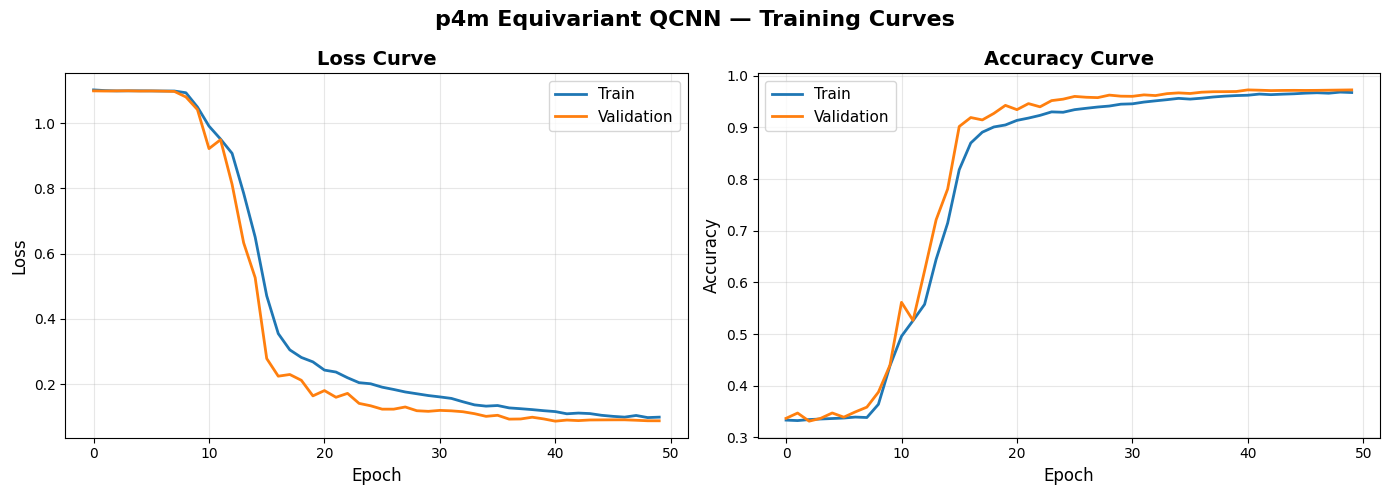

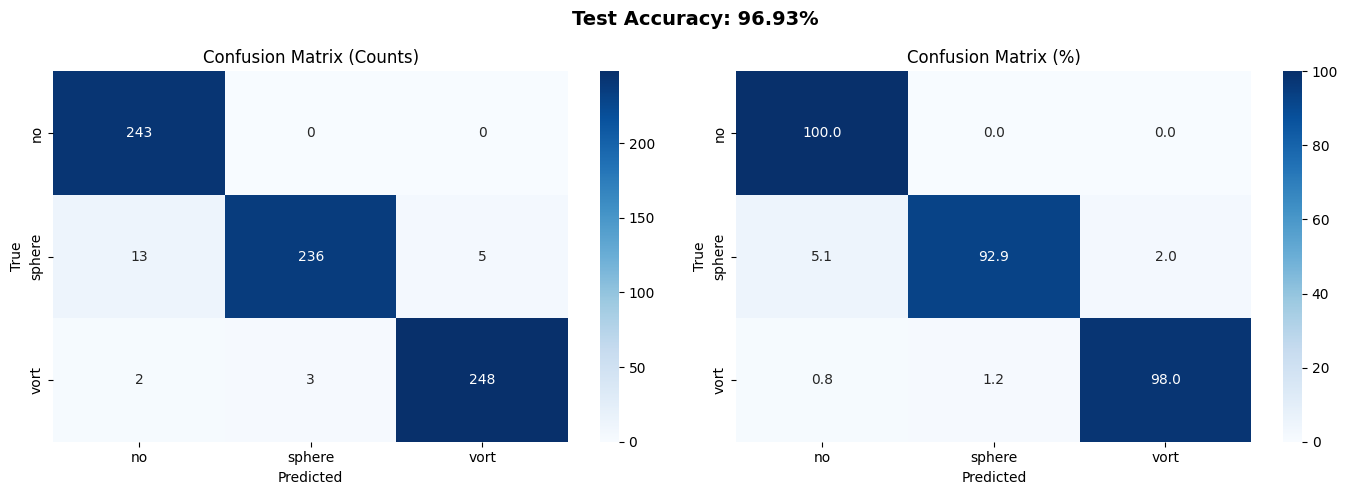


Classification Report:
              precision    recall  f1-score   support

          no     0.9419    1.0000    0.9701       243
      sphere     0.9874    0.9291    0.9574       254
        vort     0.9802    0.9802    0.9802       253

    accuracy                         0.9693       750
   macro avg     0.9698    0.9698    0.9692       750
weighted avg     0.9702    0.9693    0.9692       750



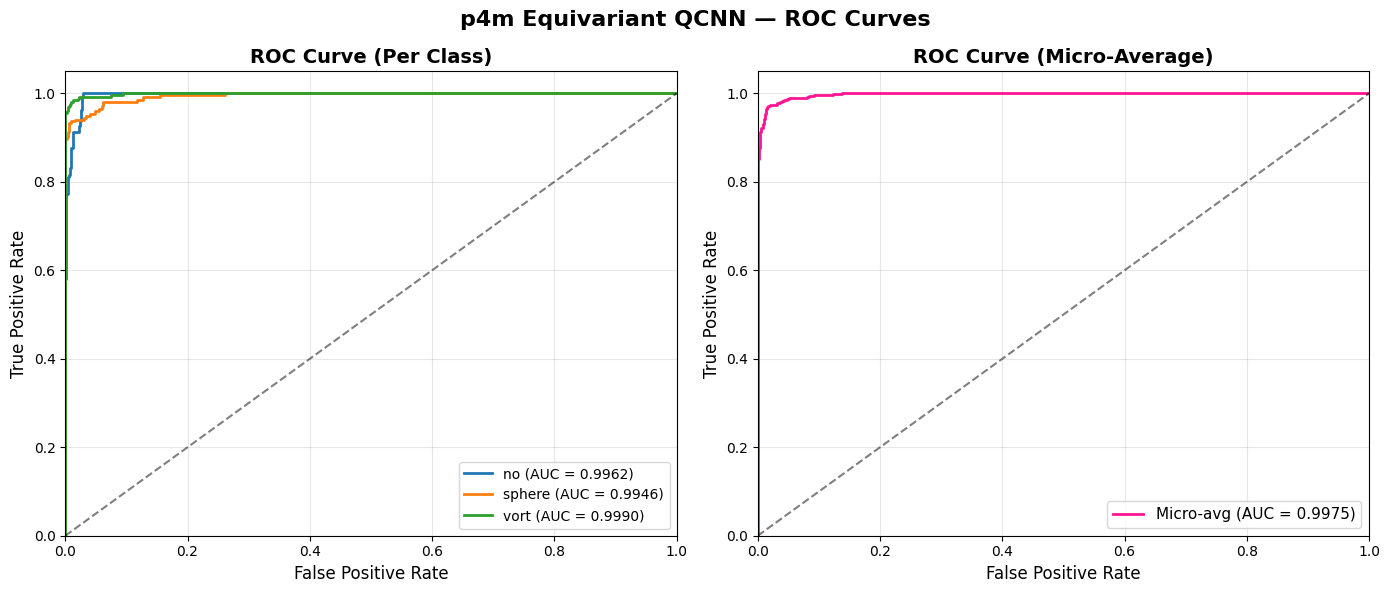


ROC-AUC Summary:
  no: AUC = 0.9962
  sphere: AUC = 0.9946
  vort: AUC = 0.9990
  Micro-avg: AUC = 0.9975


In [23]:
test_acc, test_preds, test_labels, test_probs, test_roc_auc = evaluate_model(
    model, test_loader, device=device
)

test_f1_macro = f1_score(test_labels, test_preds, average='macro')
test_f1_weighted = f1_score(test_labels, test_preds, average='weighted')

print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test ROC-AUC:  {test_roc_auc:.4f}")
print(f"Test F1 (macro):    {test_f1_macro:.4f}")
print(f"Test F1 (weighted): {test_f1_weighted:.4f}")

plot_training_history(history)
cm = plot_confusion_matrix(test_labels, test_preds, class_names, test_acc)

print("\nClassification Report:")
print(classification_report(test_labels, test_preds,
                            target_names=class_names, digits=4))

roc_auc_dict = plot_roc_curves(test_labels, test_probs, class_names)

print("\nROC-AUC Summary:")
print("=" * 50)
for i, cls in enumerate(class_names):
    print(f"  {cls}: AUC = {roc_auc_dict[i]:.4f}")
print(f"  Micro-avg: AUC = {roc_auc_dict['micro']:.4f}")

In [27]:
torch.save({
    'model_state_dict': model.state_dict(),
    'best_val_acc': max(history['val_acc']),
    'test_acc': test_acc,
    'test_roc_auc': test_roc_auc,
    'history': history,
    'class_names': class_names,
    'n_qubits': n_qubits,
    'img_size': img_size,
    'num_classes': num_classes,
}, 'best_equiv_qcnn.pth')

print("Weights saved to best_equiv_qcnn.pth")
print(f"  Val Accuracy:  {max(history['val_acc'])*100:.2f}%")
print(f"  Test Accuracy: {test_acc*100:.2f}%")
print(f"  Test ROC-AUC:  {test_roc_auc:.4f}")

Weights saved to best_equiv_qcnn.pth
  Val Accuracy:  97.24%
  Test Accuracy: 96.93%
  Test ROC-AUC:  0.9966


In [26]:
total_time = time.time() - start_time

print("=" * 60)
print("  p4m Equivariant QCNN — Final Summary")
print("=" * 60)
print(f"\nArchitecture: Hybrid qCNN + p4m Equivariant QCNN")
print(f"  Quantum backend: TorchQuantum")
print(f"\nQuantum Circuit:")
print(f"  Qubits: {n_qubits}")
print(f"  Conv gates: 3 layers of equivariant U2 (RX+IsingZZ+RX+IsingYY)")
print(f"  Pool gates: 3 layers of equivariant pooling (RX+RY+RZ+CRX)")
print(f"  Trainable quantum params: {params['quantum']}")

print(f"\nPerformance:")
print(f"  Best Validation Accuracy: {max(history['val_acc'])*100:.2f}%")
print(f"  Test Accuracy: {test_acc*100:.2f}%")
print(f"  Test ROC-AUC: {test_roc_auc:.4f}")
print(f"  Test F1 (macro): {test_f1_macro:.4f}")
print(f"  Test F1 (weighted): {test_f1_weighted:.4f}")

print(f"\nPer-Class Test Accuracy:")
cm_arr = confusion_matrix(test_labels, test_preds)
for i, cls in enumerate(class_names):
    class_acc = cm_arr[i, i] / cm_arr[i].sum() * 100
    print(f"  {cls}: {class_acc:.2f}%")

print(f"\nTraining Time: {total_time // 60:.0f}m {total_time % 60:.0f}s")
print(f"Total Parameters: {params['total']:,}")
print("=" * 60)

  p4m Equivariant QCNN — Final Summary

Architecture: Hybrid qCNN + p4m Equivariant QCNN
  Quantum backend: TorchQuantum

Quantum Circuit:
  Qubits: 8
  Conv gates: 3 layers of equivariant U2 (RX+IsingZZ+RX+IsingYY)
  Pool gates: 3 layers of equivariant pooling (RX+RY+RZ+CRX)
  Trainable quantum params: 33

Performance:
  Best Validation Accuracy: 97.24%
  Test Accuracy: 96.93%
  Test ROC-AUC: 0.9966
  Test F1 (macro): 0.9692
  Test F1 (weighted): 0.9692

Per-Class Test Accuracy:
  no: 100.00%
  sphere: 92.91%
  vort: 98.02%

Training Time: 148m 33s
Total Parameters: 8,914,060
